In [1]:
%load_ext autoreload
import numpy as np
from utils.data_loader import *
from models import *
import torch.optim as optim
import torch
import torch.nn as nn
import l4casadi
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from shred_config_tester import make_shred_config
from forecaster_config_tester import make_forecaster_datasets, make_forecaster, remove_sensor, testing_forecaster, make_sym, single_shooting_mpc
import plotly.graph_objects as go
from utils.utilities import TimeSeriesDataset, integrate_series, make_Xseqs
import do_mpc
import casadi as cas
import time

/home/abhyu/miniconda3/envs/shred_env/lib/python3.11/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/home/abhyu/miniconda3/envs/shred_env/lib/python3.11/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')


In [2]:
c1_picker = torch.tensor(np.loadtxt('data/core_regions/c1_picker.txt'), dtype=torch.float32)
c2_picker = torch.tensor(np.loadtxt('data/core_regions/c2_picker.txt'), dtype=torch.float32)
sus_picker = torch.tensor(np.loadtxt('data/core_regions/sus_picker.txt'), dtype=torch.float32)
outer_wall_picker = torch.tensor(np.loadtxt('data/core_regions/outer_wall_picker.csv'), dtype=torch.float32)
pyro_picker = torch.tensor(np.loadtxt('data/core_regions/pyro_picker.csv'), dtype=torch.float32).reshape(1,-1)
picker = torch.cat([c1_picker, c2_picker, -1*sus_picker])

c1_target = 2000
c2_target = 2000
sus_target = -2500
target = torch.cat([c1_target*torch.ones((c1_picker.shape[0],1)), c2_target*torch.ones((c2_picker.shape[0],1)), sus_target*torch.ones((sus_picker.shape[0],1))]).T

In [3]:
c1_picker_avg = c1_picker.mean(dim=0,keepdim=True)
c2_picker_avg = c2_picker.mean(dim=0,keepdim=True)
sus_picker_avg = sus_picker.mean(dim=0,keepdim=True)
outer_picker_avg = outer_wall_picker.mean(dim=0, keepdim=True)

In [4]:
picker_avg = torch.cat([c1_picker_avg,  c2_picker_avg, sus_picker_avg, pyro_picker, outer_picker_avg],dim=0)

In [5]:
configs = {
    1: [
        ['Power 3D (kW)', 'Input Energy 3D (kWh)', 'Cooling Energy 3D (kWh)', 'Pyro 3D (°C)'], 
        ['zero','init','init','init']
        ],
    2: [['Power 3D (kW)', 'Cooling Power 3D (kW)', 'Net Energy 3D (kWh)', 'Pyro 3D (°C)'],
        ['zero','zero','init','init']
        ],
    3: [['']]
}
shred1, train_dataset, valid_dataset, test_dataset, manager1 = make_shred_config(configs[1][0], padding_key=configs[1][1], state_dict_file='shred_configs/config1.json')
shred2, train_dataset_, valid_dataset_, test_dataset_, manager2 = make_shred_config(configs[2][0], padding_key=configs[2][1], state_dict_file='shred_configs/config2.json')

/home/abhyu/Documents/SINTEF/Gitlab/clean_start/utils/utilities.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.stdev = torch.tensor(np.sqrt(self.var), dtype =torch.float32)
/home/abhyu/Documents/SINTEF/Gitlab/clean_start/utils/utilities.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.stdev = torch.tensor(np.sqrt(self.var), dtype =torch.float32)


In [6]:
u_min = torch.cat([manager1.Xscaler.min ,manager2.Xscaler.min[1:-1]])
u_max = torch.cat([manager1.Xscaler.max ,manager2.Xscaler.max[1:-1]])
pmin, Emin, Cmin, pyromin, p_coolmin, E_netmin = u_min.numpy()
pmax, Emax, Cmax, pyromax, p_coolmax, E_netmax = u_max.numpy()


In [7]:
train_mu_synth = {}
valid_mu_synth = {}
test_mu_synth = {}
for k in manager1.train_mu:
    mu1 = manager1.train_mu[k]['mu']#
    mu2 = manager2.train_mu[k]['mu']#
    mu = np.hstack([mu1,mu2[:,1:3]])
    p_heat = mu[:,0].reshape(-1,1)
    E_synth = integrate_series(p_heat)
    temp = manager1.train_data[k]['temps'].T
    pyro_synth = temp @ pyro_picker.numpy().T
    p_cool_synth = 1.07*20*(temp @ outer_picker_avg.numpy().T - 20)
    C_synth = integrate_series(p_cool_synth)
    E_net_synth = E_synth - C_synth

    p_heat = (p_heat - pmin) / (pmax - pmin)
    E_synth = (E_synth - Emin) / (Emax - Emin)
    C_synth = (C_synth - Cmin) / (Cmax - Cmin)
    pyro_synth = (pyro_synth - pyromin) / (pyromax - pyromin)
    p_cool_synth = (p_cool_synth - p_coolmin) / (p_coolmax - p_coolmin)
    E_net_synth = (E_net_synth - E_netmin) / (E_netmax - E_netmin)

    train_mu_synth[k] = np.hstack([p_heat,E_synth,C_synth,pyro_synth,p_cool_synth,E_net_synth])

for k in manager1.valid_mu:
    mu1 = manager1.valid_mu[k]['mu']#
    mu2 = manager2.valid_mu[k]['mu']#
    mu = np.hstack([mu1,mu2[:,1:3]])
    p_heat = mu[:,0].reshape(-1,1)
    E_synth = integrate_series(p_heat)
    temp = manager1.valid_data[k]['temps'].T
    pyro_synth = temp @ pyro_picker.numpy().T
    p_cool_synth = 1.07*20*(temp @ outer_picker_avg.numpy().T - 20)
    C_synth = integrate_series(p_cool_synth)
    E_net_synth = E_synth - C_synth

    p_heat = (p_heat - pmin) / (pmax - pmin)
    E_synth = (E_synth - Emin) / (Emax - Emin)
    C_synth = (C_synth - Cmin) / (Cmax - Cmin)
    pyro_synth = (pyro_synth - pyromin) / (pyromax - pyromin)
    p_cool_synth = (p_cool_synth - p_coolmin) / (p_coolmax - p_coolmin)
    E_net_synth = (E_net_synth - E_netmin) / (E_netmax - E_netmin)

    valid_mu_synth[k] = np.hstack([p_heat,E_synth,C_synth,pyro_synth,p_cool_synth,E_net_synth])

for k in manager1.test_mu:
    mu1 = manager1.test_mu[k]['mu']#
    mu2 = manager2.test_mu[k]['mu']#
    mu = np.hstack([mu1,mu2[:,1:3]])
    p_heat = mu[:,0].reshape(-1,1)
    E_synth = integrate_series(p_heat)
    temp = manager1.test_data[k]['temps'].T
    pyro_synth = temp @ pyro_picker.numpy().T
    p_cool_synth = 1.07*20*(temp @ outer_picker_avg.numpy().T - 20)
    C_synth = integrate_series(p_cool_synth)
    E_net_synth = E_synth - C_synth

    p_heat = (p_heat - pmin) / (pmax - pmin)
    E_synth = (E_synth - Emin) / (Emax - Emin)
    C_synth = (C_synth - Cmin) / (Cmax - Cmin)
    pyro_synth = (pyro_synth - pyromin) / (pyromax - pyromin)
    p_cool_synth = (p_cool_synth - p_coolmin) / (p_coolmax - p_coolmin)
    E_net_synth = (E_net_synth - E_netmin) / (E_netmax - E_netmin)

    test_mu_synth[k] = np.hstack([p_heat,E_synth,C_synth,pyro_synth,p_cool_synth,E_net_synth])


In [8]:
seq_len=10
padding_key = ['zero', 'init', 'init', 'init', 'zero', 'init'] + ['init']*64

datasetX = []
datasetY = []
for k in train_mu_synth:
    x1 = torch.tensor(train_mu_synth[k],dtype=torch.float32)
    # print(x1.shape)
    x2 = shred1.lstm(manager1.train_mu[k]['scaled_mu_seqs']).detach()
    x = torch.cat([x1,x2],dim=1)[:-1,:]
    x2next = x2[1:,:]
    # print(x.shape)
    xprev = make_Xseqs(x, seq_len, padding_key=padding_key)
    datasetX.append(xprev)
    datasetY.append(x2next)
datasetX = torch.cat(datasetX)
datasetY = torch.cat(datasetY)
train_forecaster_synth =  utilities.TimeSeriesDataset(datasetX, datasetY)
datasetX = []
datasetY = []
for k in valid_mu_synth:
    x1 = torch.tensor(valid_mu_synth[k],dtype=torch.float32)
    # print(x1.shape)
    x2 = shred1.lstm(manager1.valid_mu[k]['scaled_mu_seqs']).detach()
    x = torch.cat([x1,x2],dim=1)[:-1,:]
    x2next = x2[1:,:]
    # print(x.shape)
    xprev = make_Xseqs(x, seq_len, padding_key=padding_key)
    datasetX.append(xprev)
    datasetY.append(x2next)
datasetX = torch.cat(datasetX)
datasetY = torch.cat(datasetY)
valid_forecaster_synth =  utilities.TimeSeriesDataset(datasetX, datasetY)
datasetX = []
datasetY = []
for k in test_mu_synth:
    x1 = torch.tensor(test_mu_synth[k],dtype=torch.float32)
    # print(x1.shape)
    x2 = shred1.lstm(manager1.test_mu[k]['scaled_mu_seqs']).detach()
    x = torch.cat([x1,x2],dim=1)[:-1,:]
    x2next = x2[1:,:]
    # print(x.shape)
    xprev = make_Xseqs(x, seq_len, padding_key=padding_key)
    datasetX.append(xprev)
    datasetY.append(x2next)
datasetX = torch.cat(datasetX)
datasetY = torch.cat(datasetY)
test_forecaster_synth =  utilities.TimeSeriesDataset(datasetX, datasetY)


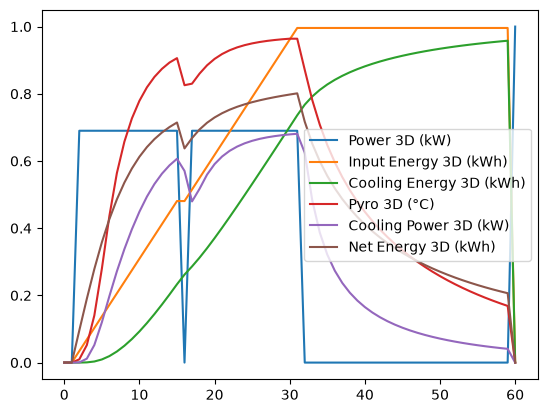

In [9]:
inputs = {_:j for j,_ in enumerate(['Power 3D (kW)', 'Input Energy 3D (kWh)', 'Cooling Energy 3D (kWh)', 'Pyro 3D (°C)', 'Cooling Power 3D (kW)', 'Net Energy 3D (kWh)'])}
for name,j in inputs.items():
    plt.plot(train_forecaster_synth.X[:61,-1,j], label=name)
plt.legend()
plt.show()


In [10]:
forecaster_configs = {
    1: ['Power 3D (kW)', 'Input Energy 3D (kWh)', 'Cooling Energy 3D (kWh)', 'Pyro 3D (°C)'],
    2: ['Power 3D (kW)', 'Input Energy 3D (kWh)', 'Cooling Energy 3D (kWh)'],
    3: ['Power 3D (kW)', 'Cooling Power 3D (kW)', 'Net Energy 3D (kWh)', 'Pyro 3D (°C)'],
    4: ['Power 3D (kW)', 'Cooling Power 3D (kW)', 'Net Energy 3D (kWh)'],
    5: ['Power 3D (kW)', 'Cooling Power 3D (kW)'],
        
}
remove_dict = {j: [k for k in range(6) if not k in [inputs[n] for n in forecaster_configs[j]]] for j in forecaster_configs}
keep_dict = {j: [inputs[n] for n in forecaster_configs[j]] for j in forecaster_configs}
forecaster_models = {}
train_forecaster_sets = {}
valid_forecaster_sets = {}
test_forecaster_sets  = {}

In [11]:
u_pickers = {}
for j in keep_dict:
    dummy = torch.zeros((len(keep_dict[j]),len(inputs)))
    for k, i in enumerate(keep_dict[j]):
        dummy[k,i] = 1
    u_pickers[j] = dummy
    np.savetxt(f'forecaster_configs/u_picker{j}.txt',dummy.detach().numpy())

In [12]:
for j in forecaster_configs:
    train_forecaster_j, valid_forecaster_j, test_forecaster_j = remove_sensor(train_forecaster_synth, valid_forecaster_synth, test_forecaster_synth, remove_idx=remove_dict[j])
    train_forecaster_sets[j] = train_forecaster_j
    valid_forecaster_sets[j] = valid_forecaster_j
    test_forecaster_sets[j]  = test_forecaster_j
    forecaster_models[j] = make_forecaster(train_forecaster_j, valid_forecaster_j, state_dict_file=f'forecaster_configs/config{j}_synth.json', lstm_params = {
                        'seq_len': 10, 
                        'n_layers': 1,
                        'hidden_dim': 64,
                        })


In [13]:
for j in range(1,train_forecaster_sets[1].X.shape[0]):
    assert (train_forecaster_sets[1].X[1,-1,4:] == train_forecaster_sets[1].Y[0]).all()

In [14]:
%autoreload 2
for j in forecaster_configs:
    print(f'-----CONFIG {j}-----')
    testing_forecaster(forecaster_models[j], shred1, manager1, train_forecaster_sets[j], valid_forecaster_sets[j], test_forecaster_sets[j], c1_picker, c2_picker, sus_picker)

-----CONFIG 1-----
-----Testing-----
POD coef MS error       :  4.864039897918701
Parseval check          :  PASSED
Temperature MS error    :  181153.40625
-----CONFIG 2-----
-----Testing-----
POD coef MS error       :  6.144349575042725
Parseval check          :  PASSED
Temperature MS error    :  421755.8125
-----CONFIG 3-----
-----Testing-----
POD coef MS error       :  5.633791923522949
Parseval check          :  PASSED
Temperature MS error    :  68304.4296875
-----CONFIG 4-----
-----Testing-----
POD coef MS error       :  4.3470683097839355
Parseval check          :  PASSED
Temperature MS error    :  164072.171875
-----CONFIG 5-----
-----Testing-----
POD coef MS error       :  6.26899528503418
Parseval check          :  PASSED
Temperature MS error    :  280406.21875


In [15]:
shred = shred1
manager=manager1
rows, cols = len(forecaster_models), 3
fig = make_subplots(rows=rows, cols=cols, subplot_titles=['Test set 1', 'Test set 2', 'Test set 3'], vertical_spacing=0.05)
for j in forecaster_models:
    print(f'Config {j}')
    for k in range(3):
        set = test_forecaster_sets[j]
        forecaster = forecaster_models[j]
        latent_pred = forecaster(set.X[k*60:(k+1)*60])
        a_pred = shred.sdn(latent_pred)
        a_pred = manager.YscalerPost.inverse_transform(a_pred)
        latent_true = set.Y[k*60:(k+1)*60]
        a_true = shred.sdn(latent_true)
        a_true = manager.YscalerPost.inverse_transform(a_true)
        Z_POD_pred = a_pred @ manager.Vtr
        Z_pred = manager.YscalerPre.inverse_transform(Z_POD_pred)
        Z_POD_true = a_true @ manager.Vtr
        Z_true = manager.YscalerPre.inverse_transform(Z_POD_true)
        c1_error = (Z_pred - Z_true)@c1_picker.T
        c2_error = (Z_pred - Z_true)@c2_picker.T
        sus_error= (Z_pred - Z_true)@sus_picker.T
        # print(f'Test set {k+1}')
        # print('C1  : ',torch.sqrt(c1_error**2).mean().item())
        # print('C2  : ',torch.sqrt(c2_error**2).mean().item())
        # print('Sus : ',torch.sqrt(c1_error**2).mean().item())

        zone_temps = {'C1': c1_error.detach(), 'C2': c2_error.detach(), 'Sus': sus_error.detach()}#, 'Shell': outer}
        colors = {name:col for name,col in zip(zone_temps.keys(), [['blue', 'rgba(0,100,255,0.2)' ], ['red', 'rgba(255,100,0,0.2)' ], ['green', 'rgba(100,255,0,0.2)' ]])}
        fig_list = []
        for name, zone in zone_temps.items().__reversed__():
            mean = zone.mean(dim=1)
            lower = zone.min(dim=1)[0]
            upper = zone.max(dim=1)[0]
            t = np.arange(len(mean))
            col1, col2 = colors[name]
                    
            fig_list += [
                go.Scatter(x=t, y=upper, mode='lines', line=dict(width=0), showlegend=False),
                go.Scatter(x=t, y=lower, mode='lines', line=dict(width=0), fill='tonexty', fillcolor=col2, name='Min–Max range',  showlegend=False),
                go.Scatter(x=t, y=mean, mode='lines', line=dict(color=col1), name=name, showlegend=False),
            ]
        # fig = go.Figure(fig_list)
        for trace in fig_list:
            fig.add_trace(trace, row=j,col=k+1)
        fig.update_yaxes(range=(-200,200), title=f'Config {j} error (°C)', row=j,col=k+1)
fig.update_xaxes(title='Timestep')
fig.update_layout(
width=1000, height=1400,
font=dict(size=10),
margin=dict(l=70, r=20, t=60, b=60),
)
fig.update_layout(title=f'Prediction reconstructoin error', legend=dict(x=0.77,y=1,bgcolor='rgba(255,255,255,0.4)'))
fig.show()   
fig.write_html('test.html')

Config 1
Config 2
Config 3
Config 4
Config 5


In [16]:
%autoreload 2
forecasters_sym = {}
folder = 'forecaster_configs/'
# wrapper = ForecasterWrapperSlidingWindow
wrapper = None
for j in(forecaster_models):
    print(j)
    model = forecaster_models[j]
    model = UnivForecasterWrapper(model, u_pickers[j])
    input_shape = (10,70)
    input_shape = (input_shape[0]*input_shape[1],1)
    output_shape = (train_forecaster_sets[j].Y.shape[-1],1)
    sym_model,sym_func,_ = make_sym(model, f'_l4c_config{j}_', input_shape, output_shape, f'forecaster_config{j}', wrapper=wrapper,jacjac=False,folder=folder)
    forecasters_sym[j] = sym_model
    

1
FOUND EXISTING l4casadi build. Loading...
Defining the casadi function
In shape :  (700, 1)
Out shape:  (64, 1)
2
FOUND EXISTING l4casadi build. Loading...
Defining the casadi function
In shape :  (700, 1)
Out shape:  (64, 1)
3
FOUND EXISTING l4casadi build. Loading...
Defining the casadi function
In shape :  (700, 1)
Out shape:  (64, 1)
4
FOUND EXISTING l4casadi build. Loading...
Defining the casadi function
In shape :  (700, 1)
Out shape:  (64, 1)
5
FOUND EXISTING l4casadi build. Loading...
Defining the casadi function
In shape :  (700, 1)
Out shape:  (64, 1)


Checking physicalness
ALL configs show inital temperature spike even when no power because forecaster has learned that the inital state always coincides with the temps going up after! Need to initialize at some other x0

1: Very non-physical, temps go up without power, settle at >1000C
2: Pretty much same
3: Temperatures initially spike,

In [17]:
Kf = torch.tensor(np.loadtxt('mpc_configs/Kmatrix.txt'),dtype=torch.float32)
Vf = torch.tensor(np.loadtxt('mpc_configs/Pmatrix.txt'),dtype=torch.float32)
u_tilde_prev = torch.tensor(np.loadtxt('mpc_configs/u_tilde_prev.txt'),dtype=torch.float32)
u_tilde = u_tilde_prev[-1].reshape(-1,)
x_tilde_prev = torch.tensor(np.loadtxt('mpc_configs/x_tilde_prev.txt'),dtype=torch.float32)
x_tilde = x_tilde_prev[-1].reshape(-1,)

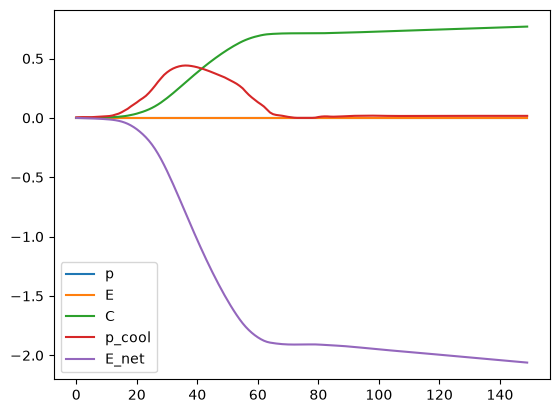

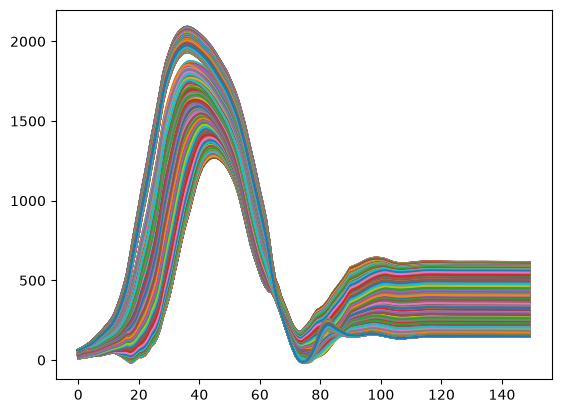

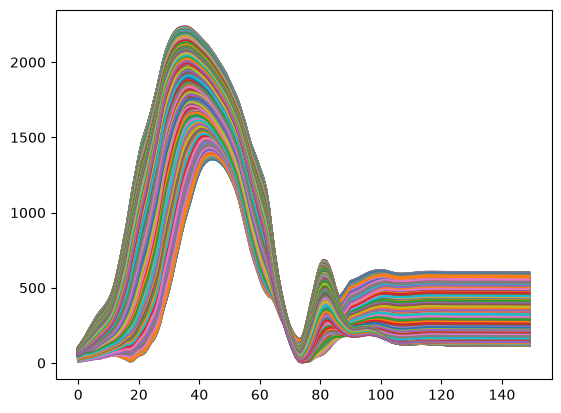

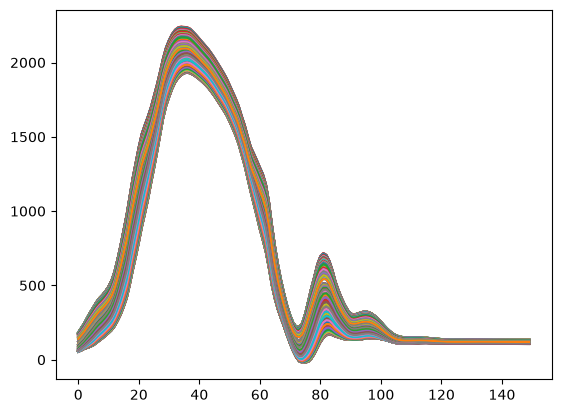

In [18]:
%autoreload 2
j=3
x0_idx = 0
frcstr = UnivForecasterWrapper(forecaster_models[j],u_picker=u_pickers[j])
f = 5
u_dim = 6#frcstr.u_dim - frcstr.out_dim
x_dim = frcstr.forecaster.out_dim
seq_len = frcstr.seq_len
u_min = torch.cat([manager1.Xscaler.min ,manager2.Xscaler.min[1:-1]])
u_max = torch.cat([manager1.Xscaler.max ,manager2.Xscaler.max[1:-1]])
horz = HorizonWrapper(
    forecaster=frcstr, 
    shred=shred1, 
    c1_picker=c1_picker, 
    c2_picker=c2_picker, 
    sus_picker=sus_picker, 
    target=target, 
    outer_picker_avg=outer_picker_avg,
    pyro_picker=pyro_picker, 
    dt=0.5,
    f=f, 
    seq_len=seq_len, 
    x_dim=x_dim,
    u_dim=u_dim,
    u_min=u_min,
    u_max=u_max,
    sus_coef=1,
    Vf=Vf,
    x_tilde=x_tilde
        )

Z0 = shred1.post(shred1.sdn(train_forecaster_synth.Y[0])).reshape(1,-1)
xhist0 = train_forecaster_synth.X[x0_idx,:,u_dim:].reshape(seq_len,x_dim)
uprev0 = train_forecaster_synth.X[x0_idx,:-1,:u_dim].reshape(seq_len-1,u_dim)
u0 = uhist0 = train_forecaster_synth.X[x0_idx,-1,:u_dim].reshape(-1,1)
E0      = u0[1].reshape(1,1)
C0      = u0[2].reshape(1,1)
pyro0   = u0[3].reshape(1,1)
p_cool0 = u0[4].reshape(1,1)
E_net0  = u0[5].reshape(1,1)
Vf_toggle = np.zeros((1,1))

pmin, Emin, Cmin, pyromin, p_coolmin, E_netmin = u_min
pmax, Emax, Cmax, pyromax, p_coolmax, E_netmax = u_max

E0 = torch.zeros((1,1))
p_test1 = torch.ones((50,1))
p_test2 = torch.zeros((150,1))
p_test = torch.cat([p_test2,p_test1, p_test2, p_test1, p_test2],dim=0)
p_test = p_test2
p_traj = []
E_traj = []
C_traj = []
pyro_traj = []
p_cool_traj = []
E_net_traj = []
x_traj = []
Z_traj = []
for p in p_test:
    p = p.reshape(1,1)
    cost,info=horz.predict_custom(p.reshape(-1,1), uprev0, xhist0, E0, C0, pyro0, p_cool0, E_net0, torch.zeros((1,1)))
    Z_next_, x_next, E0, C0, pyro0, p_cool0, E_net0, xhist0_, uprev0 = info
    # if Z_next_.min() < Z_next.min() and p == 0:
    #     Z_next_ = Z_next
    #     xhist0_ = xhist0
    if p_cool0 < 0:
        p_cool0*=0
    if C0 < 0:
        C0*=0

    xhist0 = xhist0_
    Z_next = Z_next_

    E_traj.append(E0)
    C_traj.append(C0)
    p_cool_traj.append(p_cool0)
    Z_traj.append(Z_next)
    E_net_traj.append(E_net0)
    x_traj.append(x_next)
Z_traj = torch.cat(Z_traj)
x_traj = torch.cat(x_traj)
E_traj = torch.cat(E_traj)
C_traj = torch.cat(C_traj)
p_cool_traj = torch.cat(p_cool_traj)
E_net_traj = torch.cat(E_net_traj)
p_cool_traj_us = p_cool_traj*(p_coolmax - p_coolmin) + p_coolmin
C_traj_us = integrate_series(p_cool_traj_us)
C_traj_1 = (C_traj_us - Cmin)/(Cmax-Cmin)
plt.plot(p_test,label='p')
plt.plot(E_traj,label='E')
plt.plot(C_traj.detach(),label='C')
plt.plot(p_cool_traj.detach(),label='p_cool')
plt.plot(E_net_traj.detach(),label='E_net')
plt.legend()
plt.show()

plt.plot((Z_traj @c1_picker.T).detach(),label='1')
plt.show()
plt.plot((Z_traj @c2_picker.T).detach(),label='2')
plt.show()
plt.plot((Z_traj @sus_picker.T).detach(),label='S')
plt.show()

LQR controller

In [21]:
def LQR_loop(Kf, cost_torch, n_max, xhist0, uprev0, u0, Z0, x_tilde, u_tilde):
    f = p_guess_warmstart.shape[0]
    seq_len = xhist0.shape[0]
    x_dim = xhist0.shape[1]
    u_dim = uprev0.shape[1]


    #INITIALIZING
    E0      = u0[1].reshape(1,1)
    C0      = u0[2].reshape(1,1)
    pyro0   = u0[3].reshape(1,1)
    p_cool0 = u0[4].reshape(1,1)
    E_net0  = u0[5].reshape(1,1)

    p_traj = []
    E_traj = []
    C_traj = []
    pyro_traj = []
    p_cool_traj = []
    E_net_traj = []
    x_traj = []
    Z_traj = [Z0]
    cost_traj = []
    for i in range(n_max):
        u_opt = Kf @ (xhist0[-1] - x_tilde) + u_tilde
        p_opt = u_opt[0].reshape(1,1)
        p_traj.append(p_opt.detach().numpy())
        E_traj.append(E0)
        C_traj.append(C0)
        pyro_traj.append(pyro0)
        p_cool_traj.append(p_cool0)
        E_net_traj.append(E_net0)

        #RUNNING WITH FIRST INPUT
        _,info = cost_torch.predict_custom(
            torch.tensor(p_opt,dtype=torch.float32).reshape(1,1),
            torch.tensor(uprev0,dtype=torch.float32).reshape(seq_len-1,u_dim),
            torch.tensor(xhist0,dtype=torch.float32).reshape(seq_len,x_dim),
            torch.tensor(E0,dtype=torch.float32).reshape(1,1),
            torch.tensor(C0,dtype=torch.float32).reshape(1,1),
            torch.tensor(pyro0,dtype=torch.float32).reshape(1,1),
            torch.tensor(p_cool0,dtype=torch.float32).reshape(1,1),
            torch.tensor(E_net0,dtype=torch.float32).reshape(1,1),
            torch.tensor(Vf_toggle,dtype=torch.float32)
            )
        Z_next, x_next, E0, C0, pyro0, p_cool0, E_net0, xhist0, uprev0 = info
        Z_next = Z_next.detach().numpy()
        x_next = x_next.detach().numpy()
        E0 = E0.detach().numpy()
        C0 = C0.detach().numpy()
        pyro0 = pyro0.detach().numpy()
        xhist0 = xhist0#.detach().numpy()
        uprev0 = uprev0.detach().numpy()
        Z_traj.append(Z_next)
        x_traj.append(x_next)

    p_traj = np.concat(p_traj)
    # E_traj = np.concat(E_traj)
    # C_traj = np.concat(C_traj)
    # pyro_traj = np.concat(pyro_traj)
    # p_cool_traj = np.concat(p_cool_traj)
    # E_net_traj = np.concat(E_net_traj)
    Z_traj = np.concat(Z_traj)
    x_traj = np.concat(x_traj)
    # cost_traj = np.concat(cost_traj)
    return p_traj, x_traj, E_traj, C_traj, pyro_traj, p_cool_traj, E_net_traj, Z_traj, cost_traj


n_max = 100
iter_max = 50
exact_hess = False
E_limit = 1.5
j = 3
xhist0 = train_forecaster_synth.X[0,:,u_dim:].reshape(seq_len,x_dim)
# xhist0 = x_traj[-10:].detach()
uprev0 = train_forecaster_synth.X[0,:-1,:u_dim].reshape(seq_len-1,u_dim).detach()
u0 = uhist0 = train_forecaster_synth.X[0,-1,:u_dim].reshape(-1,1).detach()
Vf_toggle = np.zeros((1,1))
Z0 = shred1.post(shred1.sdn(train_forecaster_synth.Y[0])).reshape(1,-1)
p_guess_warmstart = np.zeros((f,1))

p_opt, x_traj, E_traj, C_traj, pyro_traj, p_cool_traj, E_net_traj, Z_traj, cost_traj = LQR_loop(Kf, horz, 10000, xhist0, uprev0, u0, Z0, x_tilde, u_tilde)


/tmp/ipykernel_8429/1546178037.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(p_opt,dtype=torch.float32).reshape(1,1),
/tmp/ipykernel_8429/1546178037.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(uprev0,dtype=torch.float32).reshape(seq_len-1,u_dim),
/tmp/ipykernel_8429/1546178037.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(xhist0,dtype=torch.float32).reshape(seq_len,x_dim),
/tmp/ipykernel_8429/1546178037.py:39: UserWarning: To copy construct from a tensor, it is recommended to u

RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

In [22]:
plt.step(np.arange(p_opt.shape[0]), p_opt)
plt.title(f'LQR power traj, forecaster config {j}')

plt.show()
plt.plot((Z_traj @ c1_picker.numpy().T).mean(axis=1),label='C1')
plt.plot((Z_traj @ c2_picker.numpy().T).mean(axis=1),label='C2')
plt.plot((Z_traj @sus_picker.numpy().T).mean(axis=1),label='S')
plt.hlines(-sus_target,xmin=0,xmax=Z_traj.shape[0],ls='dashed',colors='black')
plt.hlines(c1_target,xmin=0,xmax=Z_traj.shape[0],ls='dashed',colors='black')
plt.legend()
plt.title(f'LQR Z traj, forecaster config {j}')
plt.show()

NameError: name 'p_opt' is not defined

In [154]:
p_opt_us = manager1.Pscaler.inverse_transform(torch.tensor(p_opt,dtype=torch.float32)).detach().numpy().reshape(-1,)

In [165]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

t = np.arange(Z_traj.shape[0])
limit = 3000

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        f"Power (input)",
        f"Temperatures"
    )
)

# --- Left subplot: power trajectory ---
fig.add_trace(
    go.Scatter(
        x=np.arange(p_opt.shape[0]),
        y=p_opt_us[:limit],
        mode="lines",
        line_shape="hv",  # equivalent to plt.step
        name="Power"
    ),
    row=1,
    col=1
)

# --- Right subplot: Z trajectories ---

fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj[:limit] @ c1_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Crucible 1"
    ),
    row=1,
    col=2
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj[:limit] @ c2_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Crucible 2"
    ),
    row=1,
    col=2
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj[:limit] @ sus_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Susceptor"
    ),
    row=1,
    col=2
)

# Horizontal target lines
fig.add_hline(
    y=-sus_target,
    line_dash="dash",
    line_color="black",
    row=1,
    col=2
)

fig.add_hline(
    y=c1_target,
    line_dash="dash",
    line_color="black",
    row=1,
    col=2
)

fig.update_yaxes(title_text='Power, kW',row=1,col=1)
fig.update_yaxes(title_text='Temperature, C',row=1,col=2)
fig.update_xaxes(title_text='Timestep')#,row=1,col=1)
fig.update_layout(
    width=1200,
    height=500,
    showlegend=True,
    template="plotly_white",
    title='LQR controller from linearised forecaster'
)

fig.show()

limit = 200

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        f"Power (input)",
        f"Temperatures"
    )
)

# --- Left subplot: power trajectory ---
fig.add_trace(
    go.Scatter(
        x=np.arange(p_opt.shape[0]),
        y=p_opt_us[:limit],
        mode="lines",
        line_shape="hv",  # equivalent to plt.step
        name="Power"
    ),
    row=1,
    col=1
)

# --- Right subplot: Z trajectories ---

fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj[:limit] @ c1_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Crucible 1"
    ),
    row=1,
    col=2
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj[:limit] @ c2_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Crucible 2"
    ),
    row=1,
    col=2
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj[:limit] @ sus_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Susceptor"
    ),
    row=1,
    col=2
)

# Horizontal target lines
fig.add_hline(
    y=-sus_target,
    line_dash="dash",
    line_color="black",
    row=1,
    col=2
)

fig.add_hline(
    y=c1_target,
    line_dash="dash",
    line_color="black",
    row=1,
    col=2
)

fig.update_yaxes(title_text='Power, kW',row=1,col=1)
fig.update_yaxes(title_text='Temperature, C',row=1,col=2)
fig.update_xaxes(title_text='Timestep')#,row=1,col=1)
fig.update_layout(
    width=1200,
    height=500,
    showlegend=True,
    template="plotly_white",
    title='LQR controller from linearised forecaster'
)

fig.show()

Single shooting - no terminal cost

In [24]:
folder = 'forecaster_configs/'
cost_l4c_models ={}
cost_torch_models = {}
jacjac=False
sus_coef=10
f = 5
for j in forecaster_configs:
    print(f'-----{j}-----')
    if not j == 3:
        continue
    frcstr = UnivForecasterWrapper(forecaster_models[j],u_picker=u_pickers[j])
    print(frcstr.forecaster.u_dim)
    u_dim = 6#frcstr.u_dim - frcstr.out_dim
    x_dim = frcstr.forecaster.out_dim
    seq_len = frcstr.seq_len
    horz = HorizonWrapper(
        forecaster=frcstr, 
        shred=shred1, 
        c1_picker=c1_picker, 
        c2_picker=c2_picker, 
        sus_picker=sus_picker, 
        target=target, 
        outer_picker_avg=outer_picker_avg,
        pyro_picker=pyro_picker, 
        dt=0.5,
        f=f, 
        seq_len=seq_len, 
        x_dim=x_dim,
        u_dim=u_dim,
        u_min=u_min,
        u_max=u_max,
        sus_coef=sus_coef,
        Vf=Vf,
        x_tilde=x_tilde,
        )
    cost_torch_models[j] = horz
    input_shape=(x_dim*seq_len + u_dim*(seq_len - 1) + 1*f + (u_dim-1)*1 + 1,1)
    horz_l4c, horz_cas, horz_grad = make_sym(horz, f'_horz_l4c_forecaster{j}_jacjac{jacjac}_suscoef{sus_coef}_f{f}_Vf', input_shape=input_shape, output_shape=(1,1),jacjac=jacjac,folder=folder)
    cost_l4c_models[j] = horz_l4c

-----1-----
-----2-----
-----3-----
68
FOUND EXISTING l4casadi build. Loading...
Defining the casadi function
In shape :  (705, 1)
Out shape:  (1, 1)
-----4-----
-----5-----


In [29]:
n_max = 100
iter_max = 50
exact_hess = False
E_limit = 1.5
j = 3
xhist0 = train_forecaster_synth.X[0,:,u_dim:].reshape(seq_len,x_dim)
# xhist0 = x_traj[-10:].detach()
uprev0 = train_forecaster_synth.X[0,:-1,:u_dim].reshape(seq_len-1,u_dim).detach()
u0 = uhist0 = train_forecaster_synth.X[0,-1,:u_dim].reshape(-1,1).detach()
Vf_toggle = np.zeros((1,1))
Z0 = shred1.post(shred1.sdn(train_forecaster_synth.Y[0])).reshape(1,-1)
p_guess_warmstart = np.zeros((f,1))

p_opt, x_traj, E_traj, C_traj, pyro_traj, p_cool_traj, E_net_traj, Z_traj, cost_traj = single_shooting_mpc(cost_l4c_models[j], cost_torch_models[j], exact_hess, n_max, iter_max, xhist0, uprev0, u0, Z0, p_guess_warmstart, E_limit, Vf_toggle, Kf=Kf.detach().numpy(), x_tilde=x_tilde.detach().numpy(), u_tilde=u_tilde.detach().numpy())


-----1-----
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  68.86 s ( 83.57ms)   8.64 s ( 10.49ms)       824
  nlp_grad_f  |  12.40 s (238.39ms)   1.56 s ( 29.94ms)        52
       total  |  82.51 s ( 82.51 s)  10.35 s ( 10.35 s)         1
time   :  10.350543022155762
iters  :  50
status :  Maximum_Iterations_Exceeded
p_guess:  [[0. 0. 0. 0. 0.]]
p_opt  :  [[0.99999997 0.99999991 0.9999999  0.99999991 0.99999954]]
-----2-----
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  21.63 s ( 86.16ms)   2.72 s ( 10.84ms)       251
  nlp_grad_f  |   6.05 s (241.98ms) 762.41ms ( 30.50ms)        25
       total  |  28.49 s ( 28.49 s)   3.57 s (  3.57 s)         1
time   :  3.574942111968994
iters  :  23
status :  Solved_To_Acceptable_Level
p_guess:  [[0.99999991 0.9999999  0.99999991 0.99999954 0.6965524 ]]
p_opt  :  [[1.00000001 1.00000001 1.00000001 1.00000001 0.99999999]]
-----3-----
      solver  :   t_proc      (avg)   t_wa

In [66]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

limit = 100
t = np.arange(limit)
p_opt_traj = manager1.Pscaler.inverse_transform(torch.tensor(p_opt).reshape(-1,1))
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        f"Power (input)",
        f"Temperatures",
        "Sensors",
        "Cost"
    ),
    vertical_spacing=0.15
)

# --- Left subplot: power trajectory ---
fig.add_trace(
    go.Scatter(
        x=t,
        y=p_opt_traj[:limit,0],
        mode="lines",
        line_shape="hv",  # equivalent to plt.step
        name="Power",
        showlegend=False
    ),
    row=1,
    col=1
)
fig.add_trace(
    go.Scatter(
        x=np.arange(limit),
        y=pyro_traj[:limit,0],
        mode="lines",
        # line_shape="hv",  # equivalent to plt.step
        name="Pyro"
    ),
    row=2,
    col=1
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=p_cool_traj[:limit,0],
        mode="lines",
        # line_shape="hv",  # equivalent to plt.step
        name="Cooling power"
    ),
    row=2,
    col=1
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=E_net_traj[:limit,0],
        mode="lines",
        # line_shape="hv",  # equivalent to plt.step
        name="Net energy"
    ),
    row=2,
    col=1
)
# --- Right subplot: Z trajectories ---

fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj[:limit] @ c1_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Crucible 1"
    ),
    row=1,
    col=2
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj[:limit] @ c2_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Crucible 2"
    ),
    row=1,
    col=2
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj[:limit] @ sus_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Susceptor"
    ),
    row=1,
    col=2
)

# Horizontal target lines
fig.add_hline(
    y=-sus_target,
    line_dash="dash",
    line_color="black",
    row=1,
    col=2
)

fig.add_hline(
    y=c1_target,
    line_dash="dash",
    line_color="black",
    row=1,
    col=2
)

fig.add_trace(
    go.Scatter(
        x=t,
        y=cost_traj[:limit,0],
        name='MPC cost',
        showlegend=False
    ),
    row=2,
    col=2
)

fig.update_yaxes(title_text='Power, kW',row=1,col=1)
fig.update_yaxes(title_text='Temperature, C',row=1,col=2)
fig.update_yaxes(title_text='Sensors, normalised',row=2,col=1)
fig.update_yaxes(title_text='MPC cost',row=2,col=2)
fig.update_xaxes(title_text='Timestep')#,row=1,col=1)
fig.update_layout(
    width=1200,
    height=800,
    showlegend=True,
    template="plotly_white",
    title='Single-shooting MPC controller w/o terminal cost'
)

fig.show()


In [ ]:
u_traj = np.hstack([p_opt.reshape(-1,1), E_traj, C_traj, pyro_traj, p_cool_traj, E_net_traj])
x_tilde_prev = x_traj[-10:]
u_tilde_prev = u_traj[-10:]

In [75]:
np.savetxt('mpc_configs/x_tilde_prev.txt', x_tilde_prev)
np.savetxt('mpc_configs/u_tilde_prev.txt', u_tilde_prev)

Single shooting - P1

In [25]:
n_max = 100
iter_max = 50
exact_hess = False
E_limit = 1.5
j = 3
xhist0 = train_forecaster_synth.X[0,:,u_dim:].reshape(seq_len,x_dim)
# xhist0 = x_traj[-10:].detach()
uprev0 = train_forecaster_synth.X[0,:-1,:u_dim].reshape(seq_len-1,u_dim).detach()
u0 = uhist0 = train_forecaster_synth.X[0,-1,:u_dim].reshape(-1,1).detach()
Vf_toggle = np.ones((1,1))
Z0 = shred1.post(shred1.sdn(train_forecaster_synth.Y[0])).reshape(1,-1)
p_guess_warmstart = np.zeros((f,1))

p_opt_vf, x_traj_vf, E_traj_vf, C_traj_vf, pyro_traj_vf, p_cool_traj_vf, E_net_traj_vf, Z_traj_vf, cost_traj_vf = single_shooting_mpc(cost_l4c_models[j], cost_torch_models[j], exact_hess, n_max, iter_max, xhist0, uprev0, u0, Z0, p_guess_warmstart, E_limit, Vf_toggle, Kf=Kf.detach().numpy(), x_tilde=x_tilde.detach().numpy(), u_tilde=u_tilde.detach().numpy())


-----1-----
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  64.07 s ( 77.66ms)   8.03 s (  9.74ms)       825
  nlp_grad_f  |  13.73 s (264.03ms)   1.99 s ( 38.35ms)        52
       total  |  79.03 s ( 79.03 s)  10.17 s ( 10.17 s)         1
time   :  10.171810865402222
iters  :  50
status :  Maximum_Iterations_Exceeded
p_guess:  [[0. 0. 0. 0. 0.]]
p_opt  :  [[0.99999997 0.99999991 0.9999999  0.99999991 0.99999954]]
-----2-----


/home/abhyu/Documents/SINTEF/Gitlab/clean_start/forecaster_config_tester.py:252: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(uprev0,dtype=torch.float32).reshape(seq_len-1,u_dim),
/home/abhyu/Documents/SINTEF/Gitlab/clean_start/forecaster_config_tester.py:253: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(xhist0,dtype=torch.float32).reshape(seq_len,x_dim),
/home/abhyu/Documents/SINTEF/Gitlab/clean_start/forecaster_config_tester.py:254: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(E0,dtype=torch.flo

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  19.87 s ( 79.17ms)   2.49 s (  9.91ms)       251
  nlp_grad_f  |   5.76 s (230.34ms) 722.54ms ( 28.90ms)        25
       total  |  26.28 s ( 26.28 s)   3.29 s (  3.29 s)         1
time   :  3.291673183441162
iters  :  23
status :  Solved_To_Acceptable_Level
p_guess:  [[0.99999991 0.9999999  0.99999991 0.99999954 0.6965524 ]]
p_opt  :  [[1.00000001 1.00000001 1.00000001 1.00000001 0.99999999]]
-----3-----
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  64.16 s ( 79.31ms)   8.05 s (  9.95ms)       809
  nlp_grad_f  |  12.13 s (233.23ms)   1.53 s ( 29.35ms)        52
       total  |  77.62 s ( 77.62 s)   9.72 s (  9.72 s)         1
time   :  9.724039077758789
iters  :  50
status :  Maximum_Iterations_Exceeded
p_guess:  [[1.00000001 1.00000001 1.00000001 0.99999999 0.63861382]]
p_opt  :  [[0.99999988 0.99999983 0.99999981 0.99999966 0.99999895]]
-----4-----
      solver  :

In [26]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

limit = 100
t = np.arange(limit)
p_opt_traj_vf = manager1.Pscaler.inverse_transform(torch.tensor(p_opt_vf).reshape(-1,1))
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        f"Power (input)",
        f"Temperatures",
        "Sensors",
        "Cost"
    ),
    vertical_spacing=0.15
)

# --- Left subplot: power trajectory ---
fig.add_trace(
    go.Scatter(
        x=t,
        y=p_opt_traj_vf[:limit,0],
        mode="lines",
        line_shape="hv",  # equivalent to plt.step
        name="Power",
        showlegend=False
    ),
    row=1,
    col=1
)
fig.add_trace(
    go.Scatter(
        x=np.arange(limit),
        y=pyro_traj_vf[:limit,0],
        mode="lines",
        # line_shape="hv",  # equivalent to plt.step
        name="Pyro"
    ),
    row=2,
    col=1
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=p_cool_traj_vf[:limit,0],
        mode="lines",
        # line_shape="hv",  # equivalent to plt.step
        name="Cooling power"
    ),
    row=2,
    col=1
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=E_net_traj_vf[:limit,0],
        mode="lines",
        # line_shape="hv",  # equivalent to plt.step
        name="Net energy"
    ),
    row=2,
    col=1
)
# --- Right subplot: Z trajectories ---

fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj_vf[:limit] @ c1_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Crucible 1"
    ),
    row=1,
    col=2
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj_vf[:limit] @ c2_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Crucible 2"
    ),
    row=1,
    col=2
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj_vf[:limit] @ sus_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Susceptor"
    ),
    row=1,
    col=2
)

# Horizontal target lines
fig.add_hline(
    y=-sus_target,
    line_dash="dash",
    line_color="black",
    row=1,
    col=2
)

fig.add_hline(
    y=c1_target,
    line_dash="dash",
    line_color="black",
    row=1,
    col=2
)

fig.add_trace(
    go.Scatter(
        x=t,
        y=cost_traj_vf[:limit,0],
        name='MPC cost',
        showlegend=False
    ),
    row=2,
    col=2
)

fig.update_yaxes(title_text='Power, kW',row=1,col=1)
fig.update_yaxes(title_text='Temperature, C',row=1,col=2)
fig.update_yaxes(title_text='Sensors, normalised',row=2,col=1)
fig.update_yaxes(title_text='MPC cost',row=2,col=2)
fig.update_xaxes(title_text='Timestep')#,row=1,col=1)
fig.update_layout(
    width=1200,
    height=800,
    showlegend=True,
    template="plotly_white",
    title='Single-shooting MPC controller w/ terminal cost'
)

fig.show()


Single shooting - Q cost

In [23]:
from models import HorizonWrapperQcost

In [28]:
%autoreload 2
folder = 'forecaster_configs/'
cost_l4c_models ={}
cost_torch_models = {}
jacjac=False
sus_coef=10
f = 5
for j in forecaster_configs:
    print(f'-----{j}-----')
    if not j == 3:
        continue
    frcstr = UnivForecasterWrapper(forecaster_models[j],u_picker=u_pickers[j])
    print(frcstr.forecaster.u_dim)
    u_dim = 6#frcstr.u_dim - frcstr.out_dim
    x_dim = frcstr.forecaster.out_dim
    seq_len = frcstr.seq_len
    horzQ = HorizonWrapperQcost(
        forecaster=frcstr, 
        shred=shred1, 
        c1_picker=c1_picker, 
        c2_picker=c2_picker, 
        sus_picker=sus_picker, 
        target=target, 
        outer_picker_avg=outer_picker_avg,
        pyro_picker=pyro_picker, 
        dt=0.5,
        f=f, 
        seq_len=seq_len, 
        x_dim=x_dim,
        u_dim=u_dim,
        u_min=u_min,
        u_max=u_max,
        sus_coef=sus_coef,
        Vf=Vf,
        x_tilde=x_tilde,
        )
    input_shape=(x_dim*seq_len + u_dim*(seq_len - 1) + 1*f + (u_dim-1)*1 + 1,1)
    horzQ_l4c, horzQ_cas, horzQ_grad = make_sym(horzQ, f'_horzQ_l4c_forecaster{j}_jacjac{jacjac}_suscoef{sus_coef}_f{f}_Vf', input_shape=input_shape, output_shape=(1,1),jacjac=jacjac,folder=folder)


-----1-----
-----2-----
-----3-----
68
No such directory, building new model...
Defining the casadi function
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])


/home/abhyu/miniconda3/envs/shred_env/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])


/home/abhyu/miniconda3/envs/shred_env/lib/python3.11/site-packages/l4casadi/l4casadi.py:221: UserWarning: Jacobian Adjoint trace could not be generated. Second-order sensitivities will not be available in CasADi.
  warnings.warn('Jacobian Adjoint trace could not be generated.'


In shape :  (705, 1)
Out shape:  (1, 1)
-----4-----
-----5-----


In [29]:
n_max = 100
iter_max = 50
exact_hess = False
E_limit = 1.5
j = 3
xhist0 = train_forecaster_synth.X[0,:,u_dim:].reshape(seq_len,x_dim)
# xhist0 = x_traj[-10:].detach()
uprev0 = train_forecaster_synth.X[0,:-1,:u_dim].reshape(seq_len-1,u_dim).detach()
u0 = uhist0 = train_forecaster_synth.X[0,-1,:u_dim].reshape(-1,1).detach()
Vf_toggle = np.zeros((1,1))
Z0 = shred1.post(shred1.sdn(train_forecaster_synth.Y[0])).reshape(1,-1)
p_guess_warmstart = np.zeros((f,1))

p_opt_Q, x_traj_Q, E_traj_Q, C_traj_Q, pyro_traj_Q, p_cool_traj_Q, E_net_traj_Q, Z_traj_Q, cost_traj_Q = single_shooting_mpc(horzQ_l4c, horzQ, exact_hess, n_max, iter_max, xhist0, uprev0, u0, Z0, p_guess_warmstart, E_limit, Vf_toggle, Kf=Kf.detach().numpy(), x_tilde=x_tilde.detach().numpy(), u_tilde=u_tilde.detach().numpy())


-----1-----
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  48.97 s ( 83.43ms)   6.14 s ( 10.46ms)       587
  nlp_grad_f  |  13.28 s (282.59ms)   2.00 s ( 42.55ms)        47
       total  |  63.41 s ( 63.41 s)   8.28 s (  8.28 s)         1
time   :  8.28205943107605
iters  :  45
status :  Solve_Succeeded
p_guess:  [[0. 0. 0. 0. 0.]]
p_opt  :  [[1.00000001 1.00000001 1.00000001 1.00000001 1.00000001]]
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
-----2-----


/home/abhyu/Documents/SINTEF/Gitlab/clean_start/forecaster_config_tester.py:252: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(uprev0,dtype=torch.float32).reshape(seq_len-1,u_dim),
/home/abhyu/Documents/SINTEF/Gitlab/clean_start/forecaster_config_tester.py:253: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(xhist0,dtype=torch.float32).reshape(seq_len,x_dim),
/home/abhyu/Documents/SINTEF/Gitlab/clean_start/forecaster_config_tester.py:254: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(E0,dtype=torch.flo

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  61.50 s ( 85.65ms)   7.73 s ( 10.77ms)       718
  nlp_grad_f  |  13.20 s (253.84ms)   1.66 s ( 31.88ms)        52
       total  |  76.13 s ( 76.13 s)   9.56 s (  9.56 s)         1
time   :  9.55750823020935
iters  :  50
status :  Maximum_Iterations_Exceeded
p_guess:  [[1.00000001 1.00000001 1.00000001 1.00000001 0.69655263]]
p_opt  :  [[1.00000001 1.00000001 1.00000001 1.         0.61181531]]
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
torch.Size([1, 4038])
-----3-----
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  62.74 s ( 85.60ms)   7.89 s ( 10.76ms)       733
  nlp_grad_f  |  13.73 s (264.11ms)   1.73 s ( 33.30ms)        52
       total  |  77.77 s ( 77.77 s)   9.78 s (  9.78 s)         1
time   :  9.781490087509155
iters  :  50
status :  Maximum_Iterations_Exceeded
p_guess:  [[1.00000001 1.00000001

In [30]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

limit = 100
t = np.arange(limit)
p_opt_traj_Q = manager1.Pscaler.inverse_transform(torch.tensor(p_opt_Q).reshape(-1,1))
fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        f"Power (input)",
        f"Temperatures",
        "Sensors",
        "Cost"
    ),
    vertical_spacing=0.15
)

# --- Left subplot: power trajectory ---
fig.add_trace(
    go.Scatter(
        x=t,
        y=p_opt_traj_Q[:limit,0],
        mode="lines",
        line_shape="hv",  # equivalent to plt.step
        name="Power",
        showlegend=False
    ),
    row=1,
    col=1
)
fig.add_trace(
    go.Scatter(
        x=np.arange(limit),
        y=pyro_traj_Q[:limit,0],
        mode="lines",
        # line_shape="hv",  # equivalent to plt.step
        name="Pyro"
    ),
    row=2,
    col=1
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=p_cool_traj_Q[:limit,0],
        mode="lines",
        # line_shape="hv",  # equivalent to plt.step
        name="Cooling power"
    ),
    row=2,
    col=1
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=E_net_traj_Q[:limit,0],
        mode="lines",
        # line_shape="hv",  # equivalent to plt.step
        name="Net energy"
    ),
    row=2,
    col=1
)
# --- Right subplot: Z trajectories ---

fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj_Q[:limit] @ c1_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Crucible 1"
    ),
    row=1,
    col=2
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj_Q[:limit] @ c2_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Crucible 2"
    ),
    row=1,
    col=2
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=(Z_traj_Q[:limit] @ sus_picker.numpy().T).mean(axis=1),
        mode="lines",
        name="Susceptor"
    ),
    row=1,
    col=2
)

# Horizontal target lines
fig.add_hline(
    y=-sus_target,
    line_dash="dash",
    line_color="black",
    row=1,
    col=2
)

fig.add_hline(
    y=c1_target,
    line_dash="dash",
    line_color="black",
    row=1,
    col=2
)

fig.add_trace(
    go.Scatter(
        x=t,
        y=cost_traj_Q[:limit,0],
        name='MPC cost',
        showlegend=False
    ),
    row=2,
    col=2
)

fig.update_yaxes(title_text='Power, kW',row=1,col=1)
fig.update_yaxes(title_text='Temperature, C',row=1,col=2)
fig.update_yaxes(title_text='Sensors, normalised',row=2,col=1)
fig.update_yaxes(title_text='MPC cost',row=2,col=2)
fig.update_xaxes(title_text='Timestep')#,row=1,col=1)
fig.update_layout(
    width=1200,
    height=800,
    showlegend=True,
    template="plotly_white",
    title='Single-shooting MPC controller w/ quadraitc cost'
)

fig.show()


In [52]:
n_max = 50
iter_max = 50
exact_hess = False
E_limit = 1.5
for j in forecaster_configs:
    xhist0 = train_forecaster_unif.X[0,:,u_dim:].reshape(seq_len,x_dim)
    uprev0 = train_forecaster_unif.X[0,:-1,:u_dim].reshape(seq_len-1,u_dim)
    u0 = uhist0 = train_forecaster_unif.X[0,-1,:u_dim].reshape(-1,1)
    Vf_toggle = np.zeros((1,1))
    Z0 = shred1.post(shred1.sdn(train_forecaster_unif.Y[0])).reshape(1,-1)
    p_guess_warmstart = np.zeros((f,1))
    
    p_opt, E_traj, C_traj, pyro_traj, p_cool_traj, E_net_traj, Z_traj, cost_traj = single_shooting_mpc(cost_l4c_models[j], cost_torch_models[j], exact_hess, n_max, iter_max, xhist0, uprev0, u0, Z0, p_guess_warmstart, E_limit, Vf_toggle)

    #PLOTS
    plt.step(np.arange(p_opt.shape[0]),p_opt, label='p')
    plt.plot(np.arange(E_traj.shape[0]),E_traj, label='E')
    plt.plot(np.arange(C_traj.shape[0]),C_traj, label='C')
    plt.plot(np.arange(pyro_traj.shape[0]),pyro_traj, label='pyro')
    plt.plot(np.arange(p_cool_traj.shape[0]),p_cool_traj, label='p_cool')
    plt.plot(np.arange(E_net_traj.shape[0]),E_net_traj, label='E_net')
    plt.title(f'MPC config {j}')
    plt.legend()
    plt.show()
    plt.plot((Z_traj @ c1_picker.numpy().T).mean(axis=1),label='C1')
    plt.plot((Z_traj @ c2_picker.numpy().T).mean(axis=1),label='C2')
    plt.plot((Z_traj @sus_picker.numpy().T).mean(axis=1),label='S')
    plt.hlines(-sus_target,xmin=0,xmax=Z_traj.shape[0],ls='dashed',colors='black')
    plt.hlines(c1_target,xmin=0,xmax=Z_traj.shape[0],ls='dashed',colors='black')
    plt.legend()
    plt.title(f'MPC config {j}')
    plt.show()


-----1-----
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |   2.33 s ( 80.33ms) 290.78ms ( 10.03ms)        29
  nlp_grad_f  |   3.12 s (239.80ms) 391.93ms ( 30.15ms)        13
       total  |   5.90 s (  5.90 s) 741.51ms (741.51ms)         1
time   :  0.7420423030853271
iters  :  11
status :  Solve_Succeeded
p_guess:  [[0. 0. 0. 0. 0.]]
p_opt  :  [[1.00000001 1.00000001 1.00000001 1.         0.99999999]]
-----2-----
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |   4.27 s ( 80.60ms) 537.17ms ( 10.14ms)        53
  nlp_grad_f  |   2.61 s (237.52ms) 327.77ms ( 29.80ms)        11
       total  |   7.38 s (  7.38 s) 926.86ms (926.86ms)         1
time   :  0.9273436069488525
iters  :  9
status :  Solve_Succeeded
p_guess:  [[1.00000001 1.00000001 1.         0.99999999 0.5       ]]
p_opt  :  [[0.99999999 0.99999998 0.99999997 0.99999994 0.9999997 ]]
-----3-----
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 23 has 0 dimension(s)

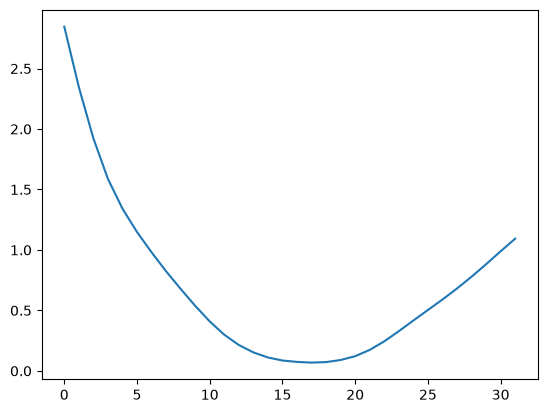

In [43]:
plt.plot(cost_traj)

-----1-----
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |   1.47 s ( 81.46ms) 184.09ms ( 10.23ms)        18
  nlp_grad_f  |   3.39 s (241.85ms) 426.58ms ( 30.47ms)        14
       total  |   5.33 s (  5.33 s) 669.83ms (669.83ms)         1
time   :  0.670313835144043
iters  :  12
status :  Solve_Succeeded
-----2-----


/tmp/ipykernel_34672/52018461.py:93: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(uprev0,dtype=torch.float32).reshape(seq_len-1,u_dim),
/tmp/ipykernel_34672/52018461.py:94: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(xhist0,dtype=torch.float32).reshape(seq_len,x_dim),
/tmp/ipykernel_34672/52018461.py:95: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(E0,dtype=torch.float32).reshape(1,1),
/tmp/ipykernel_34672/52018461.py:96: UserWarning: To copy construct from a tensor, it is recommended to use sour

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  26.37 s ( 85.90ms)   3.33 s ( 10.84ms)       307
  nlp_grad_f  |   6.06 s (252.31ms) 759.19ms ( 31.63ms)        24
       total  |  33.23 s ( 33.23 s)   4.18 s (  4.18 s)         1
time   :  4.183713912963867
iters  :  22
status :  Solve_Succeeded
-----3-----
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  24.56 s ( 80.27ms)   3.07 s ( 10.04ms)       306
  nlp_grad_f  |   5.56 s (241.55ms) 699.02ms ( 30.39ms)        23
       total  |  30.83 s ( 30.83 s)   3.87 s (  3.87 s)         1
time   :  3.867387294769287
iters  :  21
status :  Solve_Succeeded
-----4-----
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  26.48 s ( 78.57ms)   3.33 s (  9.87ms)       337
  nlp_grad_f  |   6.09 s (234.41ms) 766.68ms ( 29.49ms)        26
       total  |  33.43 s ( 33.43 s)   4.19 s (  4.19 s)         1
time   :  4.191849946975708
iters  :  24
status : 

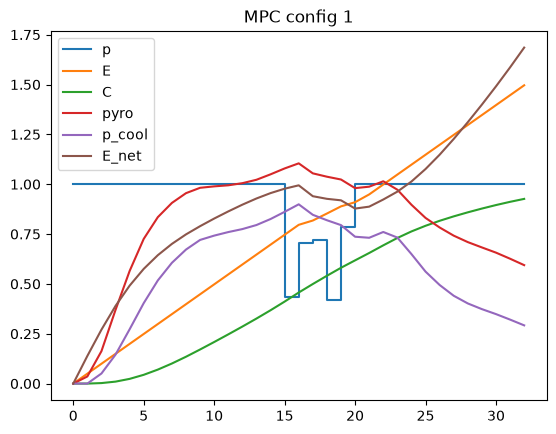

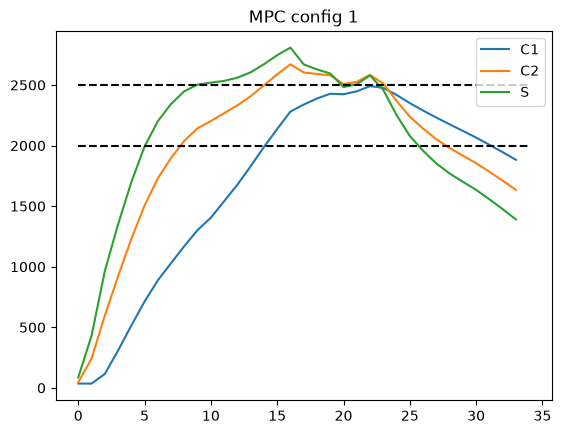

In [33]:
n_max = 50
iter_max = 100
exact_hess = False
E_limit = 1.5

for j in forecaster_configs:
    hessian_modes = {True:'exact',False:'limited-memory'}
    if j > 1:
        break
    cost_l4c = cost_l4c_models[j]
    cost_torch = cost_torch_models[j]
    p_guess = cas.MX.sym('p_guess', f, 1)
    params  = cas.MX.sym('params', input_shape[0]-f, 1)  # xhist0, uprev0, E0, C0, pyro0, flattened

    flat_in = cas.vertcat(p_guess, params)
    out = cost_l4c(flat_in)
    cost = out[0]
    # x_traj = out[1:]  # if you need bounds/constraints on the state trajectory

    nlp = {
        'x': p_guess, 
        'p': params, 
        'f': cost, 
        # 'g': x_traj}  # g optional, only if constraining x
    }
    opts = {'ipopt': {
            'max_iter': 50,
            'delta': 0.5,
            'bound_push': 1e-6,
            'bound_frac': 1e-6,
            'print_level': 1,
            # 'check_derivatives_for_naninf': 'yes',
            'hessian_approximation': hessian_modes[exact_hess],  # avoid exact Hessian computation
            }}
    solver = cas.nlpsol('solver', 'ipopt', nlp, opts)

    #INITIALIZING
    xhist0 = train_forecaster_unif.X[0,:,u_dim:].reshape(seq_len,x_dim)
    uprev0 = train_forecaster_unif.X[0,:-1,:u_dim].reshape(seq_len-1,u_dim)
    u0 = uhist0 = train_forecaster_unif.X[0,-1,:u_dim].reshape(-1,1)
    E0      = u0[1].reshape(1,1)
    C0      = u0[2].reshape(1,1)
    pyro0   = u0[3].reshape(1,1)
    p_cool0 = u0[4].reshape(1,1)
    E_net0  = u0[5].reshape(1,1)
    Vf_toggle = np.zeros((1,1))
    Z0 = shred1.post(shred1.sdn(train_forecaster_unif.Y[0])).reshape(1,-1)


    p_traj = []
    E_traj = []
    C_traj = []
    pyro_traj = []
    p_cool_traj = []
    E_net_traj = []
    Z_traj = [Z0]
    cost_traj = []
    for i in range(n_max):
        if E0 > E_limit:
            print('MAX ENERGY LIMIT')
            break
        print(f'-----{i+1}-----')
        params0 = np.vstack([uprev0.reshape(-1,1), xhist0.reshape(-1,1), E0, C0, pyro0, p_cool0, E_net0, Vf_toggle])
        # each MPC step:
        p_guess_warmstart = np.ones((f,1))

        t0 = time.time()
        sol = solver(
            x0=p_guess_warmstart, 
            p=params0,
            lbx=np.zeros_like(p_guess_warmstart), 
            ubx=np.ones_like(p_guess_warmstart), 
            # lbg=x_lb, 
            # ubg=x_ub
            )
        print('time   : ', time.time()-t0)
        print('iters  : ', solver.stats()['iter_count'])
        print('status : ',solver.stats()['return_status'])

        p_opt = np.array(sol['x']).reshape(f,1)
        cost_traj.append(np.array(sol['f']))

        p_traj.append(p_opt[0])
        E_traj.append(E0)
        C_traj.append(C0)
        pyro_traj.append(pyro0)
        p_cool_traj.append(p_cool0)
        E_net_traj.append(E_net0)

        #RUNNING WITH FIRST INPUT
        _,info = cost_torch.predict_custom(
            torch.tensor(p_opt[0],dtype=torch.float32).reshape(1,1),
            torch.tensor(uprev0,dtype=torch.float32).reshape(seq_len-1,u_dim),
            torch.tensor(xhist0,dtype=torch.float32).reshape(seq_len,x_dim),
            torch.tensor(E0,dtype=torch.float32).reshape(1,1),
            torch.tensor(C0,dtype=torch.float32).reshape(1,1),
            torch.tensor(pyro0,dtype=torch.float32).reshape(1,1),
            torch.tensor(p_cool0,dtype=torch.float32).reshape(1,1),
            torch.tensor(E_net0,dtype=torch.float32).reshape(1,1),
            torch.tensor(Vf_toggle,dtype=torch.float32)
            )

        
        Z_next, x_next, E0, C0, pyro0, p_cool0, E_net0, xhist0, uprev0 = info
        Z_next = Z_next.detach().numpy()
        E0 = E0.detach().numpy()
        C0 = C0.detach().numpy()
        pyro0 = pyro0.detach().numpy()
        xhist0 = xhist0.detach().numpy()
        uprev0 = uprev0.detach().numpy()
        Z_traj.append(Z_next)

    p_opt = np.concat(p_traj)
    E_traj = np.concat(E_traj)
    C_traj = np.concat(C_traj)
    pyro_traj = np.concat(pyro_traj)
    p_cool_traj = np.concat(p_cool_traj)
    E_net_traj = np.concat(E_net_traj)
    Z_traj = np.concat(Z_traj)
    cost_traj = np.concat(cost_traj)
    # apply p_opt[0]  # receding horizon: use only the first control

    #PLOTS
    plt.step(np.arange(p_opt.shape[0]),p_opt, label='p')
    plt.plot(np.arange(E_traj.shape[0]),E_traj, label='E')
    plt.plot(np.arange(C_traj.shape[0]),C_traj, label='C')
    plt.plot(np.arange(pyro_traj.shape[0]),pyro_traj, label='pyro')
    plt.plot(np.arange(p_cool_traj.shape[0]),p_cool_traj, label='p_cool')
    plt.plot(np.arange(E_net_traj.shape[0]),E_net_traj, label='E_net')
    plt.title(f'MPC config {j}')
    plt.legend()
    plt.show()
    plt.plot((Z_traj @ c1_picker.numpy().T).mean(axis=1),label='C1')
    plt.plot((Z_traj @ c2_picker.numpy().T).mean(axis=1),label='C2')
    plt.plot((Z_traj @sus_picker.numpy().T).mean(axis=1),label='S')
    plt.hlines(-sus_target,xmin=0,xmax=Z_traj.shape[0],ls='dashed',colors='black')
    plt.hlines(c1_target,xmin=0,xmax=Z_traj.shape[0],ls='dashed',colors='black')
    plt.legend()
    plt.title(f'MPC config {j}')
    plt.show()


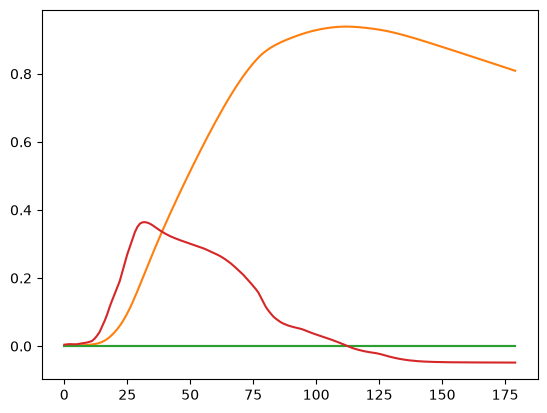

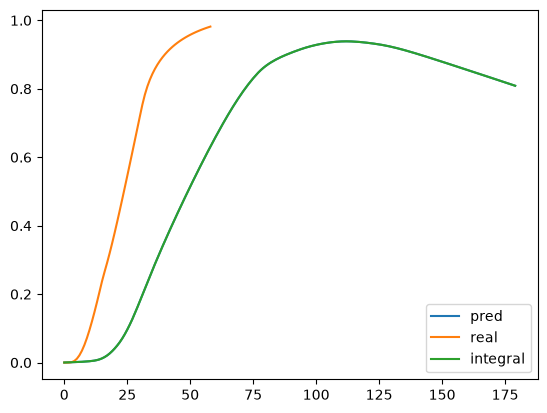

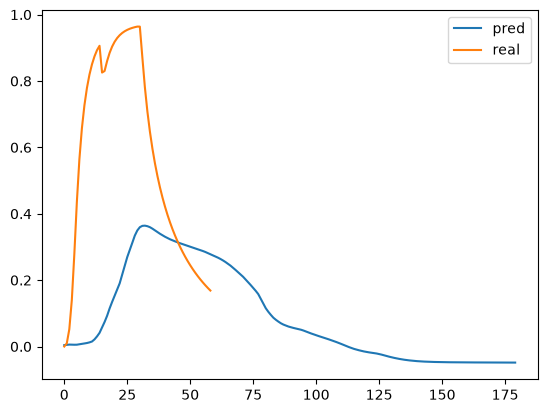

In [81]:
%autoreload 2
j=2
frcstr = UnivForecasterWrapper(forecaster_models[j],u_picker=u_pickers[j])
f = 5
u_dim = 6#frcstr.u_dim - frcstr.out_dim
x_dim = frcstr.forecaster.out_dim
seq_len = frcstr.seq_len
u_min = torch.cat([manager1.Xscaler.min ,manager2.Xscaler.min[1:-1]])
u_max = torch.cat([manager1.Xscaler.max ,manager2.Xscaler.max[1:-1]])
horz = HorizonWrapper(
    forecaster=frcstr, 
    shred=shred1, 
    c1_picker=c1_picker, 
    c2_picker=c2_picker, 
    sus_picker=sus_picker, 
    target=target, 
    outer_picker_avg=outer_picker_avg,
    pyro_picker=pyro_picker, 
    dt=0.5,
    f=f, 
    seq_len=seq_len, 
    x_dim=x_dim,
    u_dim=u_dim,
    u_min=u_min,
    u_max=u_max,
    sus_coef=sus_coef,
        )

xhist0 = train_forecaster_unif.X[0,:,u_dim:].reshape(seq_len,x_dim)
uprev0 = train_forecaster_unif.X[0,:-1,:u_dim].reshape(seq_len-1,u_dim)
u0 = uhist0 = train_forecaster_unif.X[0,-1,:u_dim].reshape(-1,1)
E0      = u0[1].reshape(1,1)
C0      = u0[2].reshape(1,1)
pyro0   = u0[3].reshape(1,1)
p_cool0 = u0[4].reshape(1,1)
E_net0  = u0[5].reshape(1,1)
Vf_toggle = np.zeros((1,1))

pmin, Emin, Cmin, pyromin, p_coolmin, E_netmin = u_min
pmax, Emax, Cmax, pyromax, p_coolmax, E_netmax = u_max

E0 = torch.zeros((1,1))
p_test1 = torch.ones((10,1))
p_test2 = torch.zeros((10,1))
p_test = torch.cat([p_test1, p_test2],dim=0)
p_test = train_forecaster_unif.X[1:60,-1,0]
p_test = 0.0*torch.ones((180,1))
C_test = train_forecaster_unif.X[1:60,-1,2]
p_cool_test = train_forecaster_unif.X[1:60,-1,4]
p_traj = []
E_traj = []
C_traj = []
pyro_traj = []
p_cool_traj = []
E_net_traj = []
Z_traj = []
for p in p_test:
    p = p.reshape(1,1)
    cost,info=horz.predict_custom(p.reshape(-1,1), uprev0, xhist0, E0, C0, pyro0, p_cool0, E_net0, torch.zeros((1,1)))
    Z_next, x_next, E0, C0, pyro0, p_cool0, E_net0, xhist0, uprev0 = info
    # if E0 > 0.9:
    #     E0 = 0.9*torch.ones((1,1))
    # if C0 > 0.9:
    #     C0 = 0.9*torch.ones((1,1))

    E_traj.append(E0)
    C_traj.append(C0)
    p_cool_traj.append(p_cool0)
    Z_traj.append(Z_next)
Z_traj = torch.cat(Z_traj)
E_traj = torch.cat(E_traj)
C_traj = torch.cat(C_traj)
p_cool_traj = torch.cat(p_cool_traj)
p_cool_traj_us = p_cool_traj*(p_coolmax - p_coolmin) + p_coolmin
C_traj_us = np.cumsum(p_cool_traj_us)*0.5
C_traj_1 = (C_traj_us - Cmin)/(Cmax-Cmin)
plt.plot(E_traj)
plt.plot(C_traj)
plt.plot(p_test)
plt.plot(p_cool_traj)
plt.show()
plt.plot(C_traj,label='pred')
plt.plot(C_test,label='real')
plt.plot(C_traj_1,label='integral')
plt.plot()
plt.legend()
plt.show()
plt.plot(p_cool_traj,label='pred')
plt.plot(p_cool_test,label='real')
plt.legend()

plt.show()

/tmp/ipykernel_34672/1544918658.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(Z_traj @c1_picker.numpy().T,label='1')


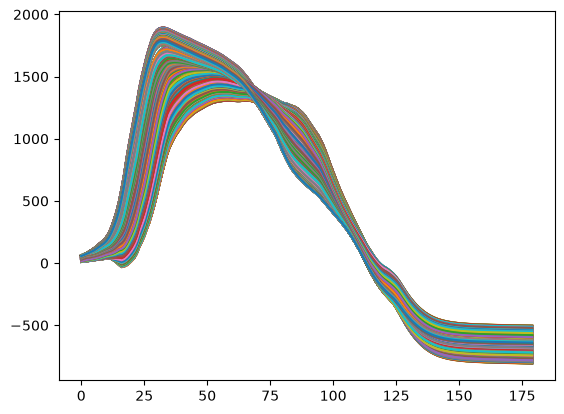

/tmp/ipykernel_34672/1544918658.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(Z_traj @c2_picker.numpy().T,label='2')


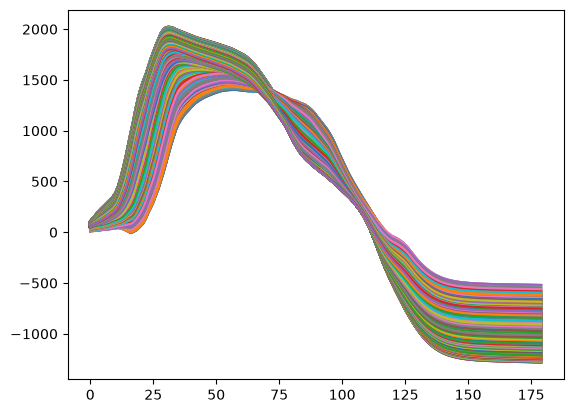

/tmp/ipykernel_34672/1544918658.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(Z_traj @sus_picker.numpy().T,label='S')


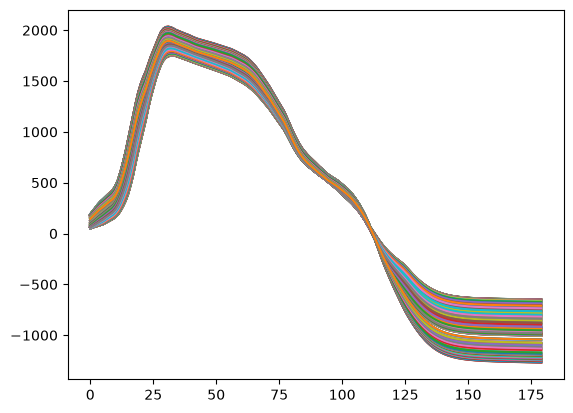

In [82]:
plt.plot(Z_traj @c1_picker.numpy().T,label='1')
plt.show()
plt.plot(Z_traj @c2_picker.numpy().T,label='2')
plt.show()
plt.plot(Z_traj @sus_picker.numpy().T,label='S')
plt.show()

Setting up do_MPC (multilpe-shooting)

In [13]:
%autoreload 2
j=1
frcstr = forecaster_models[j]
f = 5
u_dim = frcstr.u_dim - frcstr.out_dim
x_dim = frcstr.out_dim


In [53]:
combined = CombinedWrapper(shred1, f, u_dim, x_dim, picker_avg)
combined_l4c, combined_cas, _ = make_sym(combined, '_combined_l4c_2_', input_shape=(x_dim,1), output_shape=(picker_avg.shape[0],1),jacjac=True)

No such directory, building new model...
Defining the casadi function


/home/abhyu/miniconda3/envs/shred_env/lib/python3.11/ast.py:418: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  return visitor(node)


In shape :  (64, 1)
Out shape:  (5, 1)


In [60]:
target = np.array([c1_target, c2_target, sus_target, 0, 0]).reshape(-1,1)
Q = np.diag([1,1,1,0,0])
target, Q

(array([[ 2000],
        [ 2000],
        [-2500],
        [    0],
        [    0]]),
 array([[1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]]))

In [84]:
j = 1
l4c_model =     forecasters_sym[j]
latent_dim = forecaster_models[j].out_dim
in_dim = forecaster_models[j].u_dim - latent_dim
seq_len = forecaster_models[j].seq_len
# 3) Build the do-mpc model in MX mode -- this is the critical part
model_type = 'discrete'  # most common if the NN predicts x_{k+1} directly
model = do_mpc.model.Model(model_type, symvar_type='MX')

uhist = model.set_variable(var_type='_x', var_name='uhist', shape=((seq_len-1)*u_dim, 1))
xhist = model.set_variable(var_type='_x', var_name='xhist', shape=(seq_len*latent_dim, 1))
dt = 0.5
p = model.set_variable(var_type='_u', var_name='pwr', shape=(1,1))
E = model.set_variable(var_type='_x', var_name='E', shape=(1,1))
C = model.set_variable(var_type='_x', var_name='C', shape=(1,1))
# pyro = model.set_variable(var_type='_x', var_name='pyro', shape=(1,1))

Z_avg = combined_l4c(xhist[-x_dim:])           # one call, pre-setup
   # build p_cool, pyro from Z_avg here, in plain CasADi
pyro = Z_avg[-2]
u = cas.vertcat(p,E,C,pyro)
#E is the integral of p (E is input energy, p in input power)
#Z = post(x) another torch function
#C is cooling energy, it depends on the Z of the previous timestep by a matrix multiplication, C = C_old + matrix*Z*dt
#pyro is also a matrix multiplication on Z

# 4) Build the NN input and call the wrapped model symbolically
u_all = cas.vertcat(uhist, u)
nn_in = cas.vertcat(u_all, xhist)          # match whatever your forecaster expects
assert l4c_model._input_shape == nn_in.shape, (l4c_model._input_shape, nn_in.shape)
x_next = l4c_model(nn_in)      # symbolic MX expression embedding the net
print(x_next.shape)
xhist_next = cas.vertcat(xhist[x_dim:],x_next)
uhist_next = cas.vertcat(uhist[u_dim:],u)
print(xhist_next.shape)

# 5) Wire it into the model
T_wall = Z_avg[-1]
p_cool = .07*10*(T_wall - 20)
model.set_rhs('E', E + p*dt)
model.set_rhs('C', C + p_cool*dt)
model.set_rhs('xhist', xhist_next)
model.set_rhs('uhist', uhist_next)
x_current = model.set_expression('x_current', xhist[-x_dim:])
Z_avg_expr = model.set_expression('Z_avg', Z_avg)  # register for reuse post-setup


model.setup()
#Post setup variables for use in cost
p = model.u['pwr']
x_current = model.aux['x_current'] 
Z_avg_expr = model.aux['Z_avg']


# 6) Continue exactly as usual
mpc = do_mpc.controller.MPC(model)
estimator = do_mpc.estimator.StateFeedback(model)

setup_mpc = {
    't_step': 1,
    'n_horizon': f,
    'nlpsol_opts': {'ipopt.hessian_approximation': 'limited-memory'},
    'store_full_solution': True,
}
mpc.set_param(**setup_mpc)

# cost_in = cas.vertcat(u, x_current)
err_avg = Z_avg_expr - target
l_term = err_avg.T @ Q @ err_avg# #stage cost for MPC, includes input, state and output cost
m_term = cas.DM(0) #no terminal cost for now
r_term = 1e-2#input rate cost

mpc.set_objective(lterm=l_term, mterm=m_term) 
mpc.set_rterm(pwr=r_term)  # still handle input regularization the normal way


(64, 1)
(640, 1)


In [85]:
# Lower bounds on states:
mpc.bounds['lower','_x', 'xhist'] = -1
mpc.bounds['lower','_x', 'uhist'] = -1
# Upper bounds on states
mpc.bounds['upper','_x', 'xhist'] = 1
mpc.bounds['upper','_x', 'uhist'] = 1

# Lower bounds on inputs:
mpc.bounds['lower','_u', 'pwr'] = 0
# Lower bounds on inputs:
mpc.bounds['upper','_u', 'pwr'] = 1


In [86]:
mpc.setup()

Ensuring correct simulator (therefore) indexing

In [173]:
simulator = do_mpc.simulator.Simulator(model)
setup_sim = {
    't_step': 1,
}
simulator.set_param(**setup_sim)
simulator.setup()

In [ ]:
fore_test = wrapper(frcstr)

for i in range(20):
    ux = train_forecaster_sets[j].X[j]
    x1 = frcstr(ux).reshape(-1,1)
    u = ux[:,:u_dim].reshape(-1,1)
    x = ux[:,u_dim:].reshape(-1,1)
    ux = torch.cat([u,x])
    x2 = fore_test(ux)
    assert (x1==x2).all()

for i in range(10):
    xhist0 = train_forecaster_sets[j].X[i,:,u_dim:].reshape(-1,1)
    uhist0 = train_forecaster_sets[j].X[i,:-1,:u_dim].reshape(-1,1)
    x0 = np.vstack([uhist0, xhist0])
    simulator.x0 = x0
    seq_now = train_forecaster_sets[j].X[i]
    u_now = seq_now[:,:u_dim].reshape(-1,1).detach()
    x_now = seq_now[:,u_dim:].reshape(-1,1).detach()
    u0 = seq_now[-1,:u_dim].reshape(-1,1).detach().numpy()
    x_expected = fore_test(torch.cat([u_now,x_now])).detach().numpy()
    next = simulator.make_step(u0=u0)
    x_next = next[-x_dim:].reshape(-1,1)
    x_next = np.array(simulator.x0['xhist'])[-x_dim:].reshape(-1,1)
    assert (x_next == x_expected).all()

In [87]:
xhist0 = train_forecaster_sets[j].X[0,:,u_dim:].reshape(-1,1)
uhist0 = train_forecaster_sets[j].X[0,:-1,:u_dim].reshape(-1,1)
params0 = np.zeros((2,1))
x0 = np.vstack([uhist0, xhist0, params0])
# simulator.x0 = x0
mpc.x0 = x0

In [ ]:
mpc.set_initial_guess()

In [88]:
u0 = np.zeros((u_dim,1))
u0 = mpc.make_step(x0)

/home/abhyu/miniconda3/envs/shred_env/lib/python3.11/site-packages/do_mpc/controller/_mpc.py:1004: UserWarning: Intial guess for the MPC was not set. The solver call is likely to fail.
  warnings.warn('Intial guess for the MPC was not set. The solver call is likely to fail.')


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:   225058
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:     4073
                     variables with only lower bounds:        0
                variables with lower and upper bounds:     2709
                     variables with only upper bounds:        0
Total number of equality constraints.................:     4068
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  8.6094150e+07 1.44e+03 1.00e+02   0.0 0.00e+00    -  0.00e+00 0.00e+00 

CasADi - 2026-07-23 16:18:44 WARNING("KeyboardInterruptException") [.../casadi/interfaces/ipopt/ipopt_nlp.cpp:132]
